## FastText

### Download Pre-trained FastText Model

**Sebelum menjalankan cell di bawah, download model terlebih dahulu:**

1. **Kunjungi**: https://fasttext.cc/docs/en/crawl-vectors.html
2. **Download**: `cc.id.300.vec.gz` (Indonesian model, ~6GB compressed, ~9GB extracted)
3. **Extract** file `.gz` menggunakan 7-Zip atau WinRAR
4. **Simpan** file `cc.id.300.vec` di folder yang sama dengan notebook ini

In [12]:
# Install dependencies untuk FastText
# Uncomment dan jalankan jika belum terinstall
# %pip install gensim
# %pip install fasttext-wheel

In [1]:
# Load Pre-trained FastText Model untuk Bahasa Indonesia
import os
import numpy as np
from gensim.models import KeyedVectors
import gensim.downloader as api
import fasttext

print("Loading pre-trained FastText model untuk Bahasa Indonesia...")
model_path = 'Pre-trained FastText Model\cc.id.300.bin'
# model_path = 'fasttext_finetuned.model'
fasttext_model = fasttext.load_model(model_path)
model_type = 'fasttext'
print("Model berhasil di-load!")

Loading pre-trained FastText model untuk Bahasa Indonesia...
Model berhasil di-load!


In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv('datafinal_preprocessed.csv')
df.head()

,IDJwb,IDPSJ,questions_clean,answerKeys_clean,answer_clean,raw_grade,max_grade,grade,labela,label
0,1,1,['ada empat macam karakter atau olah yang dius...,['olah pikir adalah berpikiran kritis dalam se...,['olah pikir adalah berpikiran kritis dalam se...,50.0,50.0,10.0,A,5
1,2,1,['ada empat macam karakter atau olah yang dius...,['olah pikir adalah berpikiran kritis dalam se...,"['karakter saling menolong', 'karakter yang ma...",30.0,50.0,6.0,C,3
2,3,1,['ada empat macam karakter atau olah yang dius...,['olah pikir adalah berpikiran kritis dalam se...,['olah hati adalah karakter yang penuh rasa da...,50.0,50.0,10.0,A,5
3,4,1,['ada empat macam karakter atau olah yang dius...,['olah pikir adalah berpikiran kritis dalam se...,"['revolusi mental', 'yang berarti kita harus m...",20.0,50.0,4.0,D,2
4,5,1,['ada empat macam karakter atau olah yang dius...,['olah pikir adalah berpikiran kritis dalam se...,['olah raga adalah memiliki karakter yang kuat...,50.0,50.0,10.0,A,5


In [3]:
# Cek struktur data
print("=== Informasi Dataset ===")
print(f"Total baris: {len(df)}")
print(f"Kolom: {list(df.columns)}")

=== Informasi Dataset ===
Total baris: 1229
Kolom: ['IDJwb', 'IDPSJ', 'questions_clean', 'answerKeys_clean', 'answer_clean', 'raw_grade', 'max_grade', 'grade', 'labela', 'label']


In [4]:
# Parse string menjadi list (karena CSV menyimpan list sebagai string)
import ast

df['questions_list'] = df['questions_clean'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df['answerKeys_list'] = df['answerKeys_clean'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df['answer_list'] = df['answer_clean'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

### Analisis Panjang Token

**Sebelum membuat embedding, kita perlu tahu distribusi panjang token untuk menentukan `seq_len` yang optimal:**

=== Analisis Panjang Token ===

--- QUESTIONS ---
Rata-rata: 30.1 token
Median: 21.0 token
Min: 6 token
Max: 130 token
Std Dev: 33.8
Percentile 75%: 23.0 token
Percentile 90%: 35.0 token
Percentile 95%: 130.0 token
Percentile 99%: 130.0 token

--- ANSWERKEYS ---
Rata-rata: 48.9 token
Median: 49.0 token
Min: 12 token
Max: 107 token
Std Dev: 22.1
Percentile 75%: 65.0 token
Percentile 90%: 76.0 token
Percentile 95%: 86.0 token
Percentile 99%: 107.0 token

--- ANSWERS ---
Rata-rata: 37.6 token
Median: 34.0 token
Min: 0 token
Max: 253 token
Std Dev: 26.0
Percentile 75%: 49.0 token
Percentile 90%: 68.0 token
Percentile 95%: 81.0 token
Percentile 99%: 120.6 token



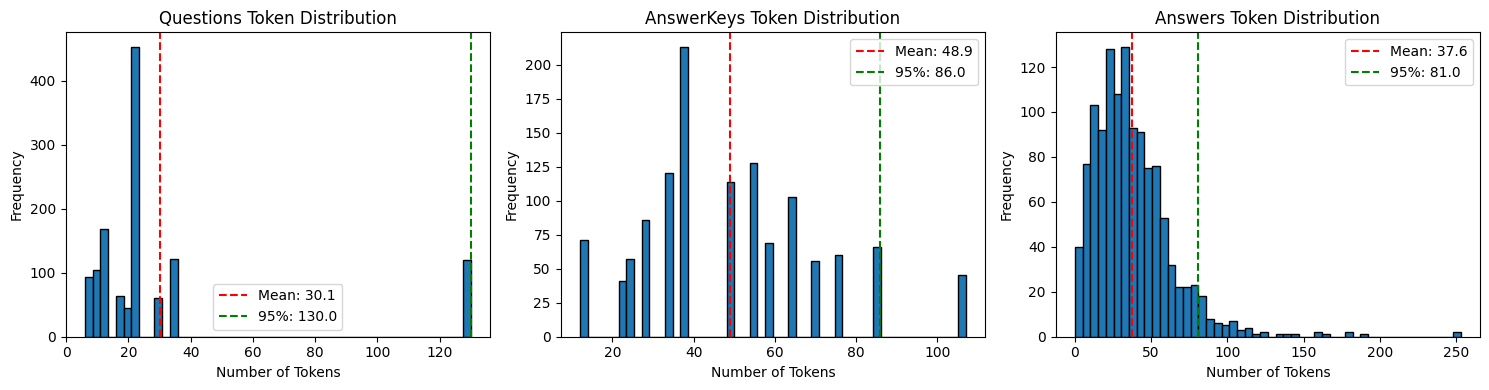


📊 REKOMENDASI SEQ_LEN

💡 Gunakan P95-P99, BUKAN nilai maksimum!
   Alasan: 1-2 outlier panjang akan menyebabkan padding berlebihan

QUESTIONS:
  ✓ Rekomendasi (95% data): SEQ_LEN_QUESTIONS = 135
  • Alternatif (99% data):  SEQ_LEN_QUESTIONS = 135
  ✗ Tidak disarankan (max): SEQ_LEN_QUESTIONS = 130

ANSWERKEYS:
  ✓ Rekomendasi (95% data): SEQ_LEN_ANSWERKEYS = 90
  • Alternatif (99% data):  SEQ_LEN_ANSWERKEYS = 110
  ✗ Tidak disarankan (max): SEQ_LEN_ANSWERKEYS = 107

ANSWERS:
  ✓ Rekomendasi (95% data): SEQ_LEN_ANSWERS = 85
  • Alternatif (99% data):  SEQ_LEN_ANSWERS = 125
  ✗ Tidak disarankan (max): SEQ_LEN_ANSWERS = 253



In [5]:
# Analisis panjang token untuk menentukan seq_len optimal
import matplotlib.pyplot as plt

def count_tokens(text_list):
    """Menghitung jumlah token dari list of strings"""
    if not text_list or len(text_list) == 0:
        return 0
    # Gabungkan semua kalimat dan hitung total token
    all_text = ' '.join(text_list)
    return len(all_text.split())

# Hitung panjang token untuk setiap kolom
print("=== Analisis Panjang Token ===\n")

results = {}
for col_name, col_data in [('questions', 'questions_list'), 
                            ('answerKeys', 'answerKeys_list'), 
                            ('answers', 'answer_list')]:
    token_lengths = df[col_data].apply(count_tokens)
    
    print(f"--- {col_name.upper()} ---")
    print(f"Rata-rata: {token_lengths.mean():.1f} token")
    print(f"Median: {token_lengths.median():.1f} token")
    print(f"Min: {token_lengths.min()} token")
    print(f"Max: {token_lengths.max()} token")
    print(f"Std Dev: {token_lengths.std():.1f}")
    print(f"Percentile 75%: {token_lengths.quantile(0.75):.1f} token")
    print(f"Percentile 90%: {token_lengths.quantile(0.90):.1f} token")
    print(f"Percentile 95%: {token_lengths.quantile(0.95):.1f} token")
    print(f"Percentile 99%: {token_lengths.quantile(0.99):.1f} token")
    print()
    
    # Simpan untuk rekomendasi
    results[col_name] = {
        'p95': token_lengths.quantile(0.95),
        'p99': token_lengths.quantile(0.99),
        'max': token_lengths.max()
    }

# Visualisasi distribusi
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (col_name, col_data) in enumerate([('Questions', 'questions_list'), 
                                                ('AnswerKeys', 'answerKeys_list'), 
                                                ('Answers', 'answer_list')]):
    token_lengths = df[col_data].apply(count_tokens)
    axes[idx].hist(token_lengths, bins=50, edgecolor='black')
    axes[idx].set_title(f'{col_name} Token Distribution')
    axes[idx].set_xlabel('Number of Tokens')
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(token_lengths.mean(), color='red', linestyle='--', label=f'Mean: {token_lengths.mean():.1f}')
    axes[idx].axvline(token_lengths.quantile(0.95), color='green', linestyle='--', label=f'95%: {token_lengths.quantile(0.95):.1f}')
    axes[idx].legend()

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("📊 REKOMENDASI SEQ_LEN")
print("="*60)
print("\n💡 Gunakan P95-P99, BUKAN nilai maksimum!")
print("   Alasan: 1-2 outlier panjang akan menyebabkan padding berlebihan\n")

for col_name, var_name in [('questions', 'SEQ_LEN_QUESTIONS'), 
                            ('answerKeys', 'SEQ_LEN_ANSWERKEYS'), 
                            ('answers', 'SEQ_LEN_ANSWERS')]:
    p95 = int(results[col_name]['p95'])
    p99 = int(results[col_name]['p99'])
    max_val = int(results[col_name]['max'])
    
    # Rekomendasi: bulatkan ke atas kelipatan 5
    rec_p95 = ((p95 // 5) + 1) * 5
    rec_p99 = ((p99 // 5) + 1) * 5
    
    print(f"{col_name.upper()}:")
    print(f"  ✓ Rekomendasi (95% data): {var_name} = {rec_p95}")
    print(f"  • Alternatif (99% data):  {var_name} = {rec_p99}")
    print(f"  ✗ Tidak disarankan (max): {var_name} = {max_val}")
    print()

### Fungsi untuk Embedding (Sequence-based untuk BiLSTM)

**PENTING**: Fungsi ini menghasilkan sequence embeddings (bukan averaged) untuk input Siamese BiLSTM  
- Setiap dokumen → matrix (seq_len, embedding_dim)
- Padding untuk sequence pendek, truncation untuk yang panjang

In [6]:
# ===== KONFIGURASI SEQ_LEN =====
# Sesuaikan dengan hasil analisis di atas

SEQ_LEN_QUESTIONS  = int(((results['questions']['p95']   // 5) + 1) * 5)
SEQ_LEN_ANSWERKEYS = int(((results['answerKeys']['p95']  // 5) + 1) * 5)
SEQ_LEN_ANSWERS    = int(((results['answers']['p95']     // 5) + 1) * 5)

EPSILON = 1e-7  # Penanda OOV: non-zero agar tidak dianggap padding, tapi mendekati nol

def get_sequence_embedding(sentences, seq_len):
    """
    Mengubah dokumen menjadi sequence embedding untuk BiLSTM.

    Alur:
    1. Tokenizing : Teks → list of words
    2. Embedding  : Setiap word → FastText vector (300 dim)
    3. OOV        : Zero vector → epsilon (non-zero, tidak dianggap padding)
    4. Padding    : Zero hanya di kanan (setelah konten)
    5. Output     : Matrix (seq_len, 300)

    Kenapa epsilon untuk OOV?
    - FastText kadang menghasilkan zero vector untuk kata OOV.
    - Zero vector = dianggap padding oleh Masking(mask_value=0.0) → posisi "hilang" di tengah.
    - Epsilon (1e-7) = non-zero → tidak ter-mask → mask selalu [True..True, False..False].
    - Syarat cuDNN terpenuhi tanpa perlu skip kata atau post-padding manual.

    Args:
        sentences : list of strings
        seq_len   : int - panjang sequence

    Returns:
        numpy array (seq_len, embedding_dim)
    """
    embedding_dim = fasttext_model.get_dimension()

    if not sentences or len(sentences) == 0:
        return np.zeros((seq_len, embedding_dim))

    if isinstance(sentences, list):
        all_text = ' '.join([str(s) for s in sentences if s and not pd.isna(s)])
    else:
        all_text = str(sentences) if not pd.isna(sentences) else ''

    words = all_text.split()[:seq_len]

    sequence = np.zeros((seq_len, embedding_dim))
    for idx, word in enumerate(words):
        vec = fasttext_model.get_word_vector(word)
        if np.linalg.norm(vec) < 1e-6:
            sequence[idx] = EPSILON        # OOV → epsilon, bukan zero
        else:
            sequence[idx] = vec
    # Posisi [len(words)..seq_len-1] tetap zero → padding di kanan ✅

    return sequence


def get_questions_embedding(sentences):
    return get_sequence_embedding(sentences, SEQ_LEN_QUESTIONS)

def get_answerkeys_embedding(sentences):
    return get_sequence_embedding(sentences, SEQ_LEN_ANSWERKEYS)

def get_answers_embedding(sentences):
    return get_sequence_embedding(sentences, SEQ_LEN_ANSWERS)


In [7]:
# ============================================================
# PROSES EMBEDDING UNTUK SEMUA DATA
# ============================================================
# Cell ini akan memproses SELURUH DataFrame 
# (berbeda dengan cell demo yang hanya memproses 1 sample)

from tqdm import tqdm
tqdm.pandas()

print("="*60)
print("🚀 MEMPROSES EMBEDDING UNTUK SEMUA DATA")
print("="*60)
print(f"\nTotal data: {len(df)} baris")
print(f"Total unique IDPSJ: {df['IDPSJ'].nunique()}\n")

# ===== 1. PROSES QUESTIONS & ANSWERKEYS =====
# Hanya untuk unique IDPSJ (karena 1 soal punya banyak jawaban)
print("="*60)
print("1️⃣ Memproses Questions & AnswerKeys (unique IDPSJ only)")
print("="*60)

unique_idpsj = df.drop_duplicates(subset='IDPSJ')[['IDPSJ', 'questions_list', 'answerKeys_list']].copy()
print(f"Memproses {len(unique_idpsj)} unique IDPSJ...")

print("\n⏳ Processing Questions...")
unique_idpsj['questions_embedding'] = unique_idpsj['questions_list'].progress_apply(get_questions_embedding)

print("\n⏳ Processing AnswerKeys...")
unique_idpsj['answerKeys_embedding'] = unique_idpsj['answerKeys_list'].progress_apply(get_answerkeys_embedding)

# Merge kembali ke df asli
df = df.merge(
    unique_idpsj[['IDPSJ', 'questions_embedding', 'answerKeys_embedding']], 
    on='IDPSJ', 
    how='left',
    suffixes=('', '_new')  # Hindari duplikasi kolom jika sudah ada
)

# Hapus kolom duplikat jika ada
if 'questions_embedding_new' in df.columns:
    df['questions_embedding'] = df['questions_embedding_new']
    df.drop('questions_embedding_new', axis=1, inplace=True)
if 'answerKeys_embedding_new' in df.columns:
    df['answerKeys_embedding'] = df['answerKeys_embedding_new']
    df.drop('answerKeys_embedding_new', axis=1, inplace=True)

print("✅ Questions & AnswerKeys selesai!\n")


# ===== 2. PROSES STUDENT ANSWERS =====
print("="*60)
print("2️⃣ Memproses Student Answers (semua baris)")
print("="*60)
print(f"Memproses {len(df)} answers...")

print("\n⏳ Processing Answers...")
df['answer_embedding'] = df['answer_list'].progress_apply(get_answers_embedding)

print("✅ Student Answers selesai!\n")


# ===== 3. VERIFIKASI HASIL =====
print("="*60)
print("✅ SEMUA EMBEDDING SELESAI DIPROSES!")
print("="*60)

print(f"\nJumlah baris: {len(df)}")
print(f"\nKolom embedding yang tersedia:")
print(f"  ✓ questions_embedding:  {df['questions_embedding'].iloc[0].shape}")
print(f"  ✓ answerKeys_embedding: {df['answerKeys_embedding'].iloc[0].shape}")
print(f"  ✓ answer_embedding:     {df['answer_embedding'].iloc[0].shape}")

🚀 MEMPROSES EMBEDDING UNTUK SEMUA DATA

Total data: 1229 baris
Total unique IDPSJ: 17

1️⃣ Memproses Questions & AnswerKeys (unique IDPSJ only)
Memproses 17 unique IDPSJ...

⏳ Processing Questions...


100%|██████████| 17/17 [00:00<00:00, 451.55it/s]



⏳ Processing AnswerKeys...


100%|██████████| 17/17 [00:00<00:00, 416.09it/s]


✅ Questions & AnswerKeys selesai!

2️⃣ Memproses Student Answers (semua baris)
Memproses 1229 answers...

⏳ Processing Answers...


100%|██████████| 1229/1229 [00:01<00:00, 1156.87it/s]

✅ Student Answers selesai!

✅ SEMUA EMBEDDING SELESAI DIPROSES!

Jumlah baris: 1229

Kolom embedding yang tersedia:
  ✓ questions_embedding:  (135, 300)
  ✓ answerKeys_embedding: (90, 300)
  ✓ answer_embedding:     (85, 300)


In [11]:
emb = df['answerKeys_embedding'].iloc[0]
emb

array([[-0.03054817, -0.03183972,  0.00459807, ..., -0.20225367,
         0.10903135,  0.11890437],
       [-0.01489312, -0.00132498,  0.01253044, ..., -0.11010166,
        -0.0396516 ,  0.10973023],
       [ 0.03270507,  0.01018852,  0.03644488, ..., -0.06707464,
         0.0139503 ,  0.02264393],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]])

In [9]:
# Proses kolom grade: konversi dari format "10,00" → integer 1-10
# Ganti koma desimal (format Indonesia) dengan titik, lalu konversi ke float → int
df['grade'] = df['grade'].astype(str).str.replace(',', '.').astype(float).round().astype(int)

# Grade 0 diubah menjadi 1 (nilai minimum valid)
df['grade'] = df['grade'].clip(lower=1)

print("Distribusi grade setelah konversi:")
print(df['grade'].value_counts().sort_index())


Distribusi grade setelah konversi:
grade
1     150
2      78
3      84
4      90
5      70
6     152
7     103
8     154
9      69
10    279
Name: count, dtype: int64


In [12]:
df = df[['IDJwb', 'IDPSJ', 'questions_embedding', 'answerKeys_embedding', 'answer_embedding', 
            'grade', 'labela']]

### Simpan Hasil Embedding

In [13]:
import os
import numpy as np

# ── Simpan hasil akhir ───────────────────────────────────────────────────────
# answers_emb : simpan penuh karena setiap sampel unik
# questions & answerkeys : simpan HANYA 1 per IDPSJ (hemat storage)
#   -> rekonstruksi di training menggunakan kolom psj_idx di metadata

print("Menyimpan hasil akhir...")

# Folder output relatif (ubah sesuai kebutuhan)
OUTPUT_DIR = "Embedding/6"
os.makedirs(OUTPUT_DIR, exist_ok=True)

answers_emb = np.stack(df['answer_embedding'].values)
questions_emb = np.stack(df['questions_embedding'].values)
answerkeys_emb = np.stack(df['answerKeys_embedding'].values)

# metadata = df[['IDJwb', 'IDPSJ', 'grade']].copy() # regresi
metadata = df[['IDJwb', 'IDPSJ', 'grade', 'labela']].copy()

# Buat mapping IDPSJ -> indeks unik
idpsj_sorted = sorted(metadata['IDPSJ'].unique())
idpsj_to_idx = {psj: i for i, psj in enumerate(idpsj_sorted)}
final_metadata = metadata.copy()
final_metadata['psj_idx'] = final_metadata['IDPSJ'].map(idpsj_to_idx)

# Ambil satu baris representatif per IDPSJ (embedding identik dalam IDPSJ)
uniq_q_rows = [final_metadata.index[final_metadata['IDPSJ'] == psj][0] for psj in idpsj_sorted]
uniq_questions_emb = questions_emb[uniq_q_rows]
uniq_answerkeys_emb = answerkeys_emb[uniq_q_rows]

# Simpan
answers_path = os.path.join(OUTPUT_DIR, 'answers_emb.npy')
questions_path = os.path.join(OUTPUT_DIR, 'questions_emb.npy')
answerkeys_path = os.path.join(OUTPUT_DIR, 'answerkeys_emb.npy')
metadata_path = os.path.join(OUTPUT_DIR, 'metadata.pkl')

np.save(answers_path, answers_emb)
np.save(questions_path, uniq_questions_emb)
np.save(answerkeys_path, uniq_answerkeys_emb)
final_metadata.to_pickle(metadata_path)

print("File tersimpan:")
print(f"  {answers_path}    {answers_emb.shape}   (per sampel)")
print(f"  {questions_path}  {uniq_questions_emb.shape}  (per IDPSJ unik)")
print(f"  {answerkeys_path} {uniq_answerkeys_emb.shape} (per IDPSJ unik)")
print(f"  {metadata_path}       {len(final_metadata)} rows  (+ kolom psj_idx)")

before_mb = (questions_emb.nbytes + answerkeys_emb.nbytes) / 1024**2
after_mb = (uniq_questions_emb.nbytes + uniq_answerkeys_emb.nbytes) / 1024**2
print(f"\nHemat storage questions+answerkeys: {before_mb:.1f} MB -> {after_mb:.1f} MB")

Menyimpan hasil akhir...
File tersimpan:
  Embedding/6\answers_emb.npy    (1229, 85, 300)   (per sampel)
  Embedding/6\questions_emb.npy  (17, 135, 300)  (per IDPSJ unik)
  Embedding/6\answerkeys_emb.npy (17, 90, 300) (per IDPSJ unik)
  Embedding/6\metadata.pkl       1229 rows  (+ kolom psj_idx)

Hemat storage questions+answerkeys: 632.9 MB -> 8.8 MB
